# Load Packages

In [2]:
import pandas as pd
import polars as pl
import numpy as np
import os
import ast
import textwrap
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
# import cv2

In [3]:
cleaned_dataset_dir = './cleaned_dataset'
original_dataset_folder = './original_dataset'

# Preparing Data

In [43]:
df = pd.read_csv(original_dataset_folder + '/uicrit_public.csv')

# Convert stringified lists to actual lists in pandas
df['comments'] = df['comments'].apply(ast.literal_eval)
df['comments_source'] = df['comments_source'].apply(ast.literal_eval)

print(df.shape)
df.head(3)

(2981, 9)


,rico_id,task,aesthetics_rating,learnability,efficency,usability_rating,design_quality_rating,comments_source,comments
0,10089,Follow events to keep track on your favorite g...,6,3.0,3,6,6,"[human, human, human, human, both, both, both]",[Comment 1\nThe expected standard is that the ...
1,10089,Explore the ACC Tournament schedules and match...,6,2.0,3,5,6,"[human, human, human, human, human, human, both]",[Comment 1\nThe expected standard is to make t...
2,10089,Check the sport's schedule .,7,4.0,4,7,7,"[human, human, human, both]",[LLM Comment 1\nThe expected standard is for U...


## Check for Nulls

In [44]:
# check null
df.isnull().sum()

rico_id                  0
task                     2
aesthetics_rating        0
learnability             1
efficency                0
usability_rating         0
design_quality_rating    0
comments_source          0
comments                 0
dtype: int64

In [45]:
# display the rows where there are nulls
null_rows = df[df.isnull().any(axis=1)]
print('Rows with null values:')
null_rows

Rows with null values:


,rico_id,task,aesthetics_rating,learnability,efficency,usability_rating,design_quality_rating,comments_source,comments
432,190,NaN,7,4.0,4,7,7,"[human, llm, both, llm]",[LLM Comment 1\nThe expected standard is The t...
1186,36445,View privacy policy and disclaimer,6,NaN,4,7,7,"[human, human, human]",[LLM Comment 1\nThe expected standard is to us...
2799,70901,NaN,6,3.0,3,6,6,"[human, human, human, human, human, both]",[Comment 1\nThe expected standard is that the ...


In [46]:
# Count number of values NOT in the specified range for each column

out_of_range_counts = {
    "aesthetics_rating": (~df["aesthetics_rating"].between(1, 10)).sum(),
    "learnability": (~df["learnability"].between(1, 5)).sum(),
    "efficency": (~df["efficency"].between(1, 5)).sum(),
    "usability_rating": (~df["usability_rating"].between(1, 10)).sum(),
    "design_quality_rating": (~df["design_quality_rating"].between(1, 10)).sum(),
}
out_of_range_counts

{'aesthetics_rating': np.int64(0),
 'learnability': np.int64(1),
 'efficency': np.int64(0),
 'usability_rating': np.int64(0),
 'design_quality_rating': np.int64(0)}

In [47]:
# drop rows with null and save the cleaned dataframe
df_notna = df.dropna().copy()

df_notna['learnability'] = df_notna['learnability'].astype(int)

# Reorder rows based on rico_id, and alphabetically by task
df_notna = df_notna.sort_values(by=['rico_id', 'task']).reset_index(drop=True)

## Remove Duplicated Screen-Task Pairs

In [48]:
# Count duplicate 'task' values
duplicate_tasks = df_notna['task'].duplicated(keep=False)

# Display all rows with duplicate 'task' values
duplicates_df = df_notna[duplicate_tasks]

# Show how many unique duplicated tasks exist
num_duplicate_tasks = duplicates_df['task'].nunique()

print(f"Number of duplicated 'task' values: {num_duplicate_tasks}")
display(duplicates_df[['rico_id', 'task']].sort_values('task'))


Number of duplicated 'task' values: 61


,rico_id,task
1435,35061,Adjust Notification Settings.
985,24203,Adjust Notification Settings.
1488,36217,Adjust the settings.
1269,30728,Adjust the settings.
59,1369,Book a Flight
...,...,...
1022,25399,View or search Japanese recipes
301,6966,View the download history
300,6966,View the download history
75,1693,View the list of gas stations


For each duplicate (task, rico_id), keep the one with more comments


In [ ]:
# Count number of comments per row
df_notna["num_comments"] = df_notna["comments"].apply(len)

# Identify rows where (task, rico_id) is duplicated
duplicate_pairs_mask = df_notna.duplicated(subset=['task', 'rico_id'], keep=False)
duplicate_pairs_df = df_notna[duplicate_pairs_mask]

# For each duplicate (task, rico_id), keep the one with more comments
idx_to_keep = (
    duplicate_pairs_df.groupby(['task', 'rico_id'])["num_comments"]
    .idxmax()
)

# Drop the rest
df_notna_deduped = df_notna.drop(index=duplicate_pairs_df.index.difference(idx_to_keep))

# Show stats
num_duplicates = duplicate_pairs_df.shape[0]
num_kept = idx_to_keep.shape[0]
num_dropped = num_duplicates - num_kept

print(f"Total duplicate (task, rico_id) rows: {num_duplicates}")
print(f"Rows kept (one per duplicate pair): {num_kept}")
print(f"Rows dropped: {num_dropped}")

Total duplicate (task, rico_id) rows: 38
Rows kept (one per duplicate pair): 19
Rows dropped: 19


Inspect tasks with nearby rico_id (±10)

In [ ]:
# Create helper DataFrame of all task duplicates across different rico_ids
task_counts = df_notna_deduped['task'].value_counts()
multi_screen_tasks = task_counts[task_counts > 1].index

# Filter rows with those tasks
multi_screen_df = df_notna_deduped[df_notna_deduped['task'].isin(multi_screen_tasks)]

# Sort by task then rico_id
multi_screen_df = multi_screen_df.sort_values(by=['task', 'rico_id'])

# For manual review: group by task, and find nearby rico_id values
for task, group in multi_screen_df.groupby('task'):
    rico_ids = group['rico_id'].sort_values().to_list()
    close_ids = [(i, j) for i in rico_ids for j in rico_ids if i < j and abs(i - j) <= 10]
    if close_ids:
        print(f"\nTask: {task}")
        print("Close rico_id pairs (within ±10):", close_ids)
        display(group[['rico_id', 'task']])



Task: Select an option to explore
Close rico_id pairs (within ±10): [(51727, 51732)]


,rico_id,task
40,802,Select an option to explore
52,1134,Select an option to explore
248,5760,Select an option to explore
276,6485,Select an option to explore
333,7588,Select an option to explore
348,7836,Select an option to explore
393,8923,Select an option to explore
751,17437,Select an option to explore
791,18281,Select an option to explore
802,18449,Select an option to explore



Task: View flights from Aalborg to Abu Dhabi
Close rico_id pairs (within ±10): [(1369, 1371)]


,rico_id,task
61,1369,View flights from Aalborg to Abu Dhabi
64,1371,View flights from Aalborg to Abu Dhabi


Image for RICO ID 51727 not found.
Image for RICO ID 51732 not found.
Image for RICO ID 1371 not found.


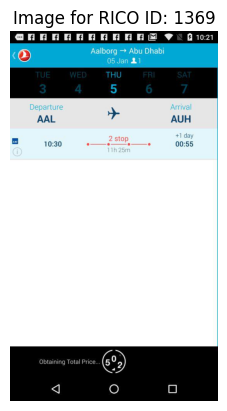

In [ ]:
# show image
def show_image(rico_id):
    img_path = f'{cleaned_dataset_dir}/used_dataset_screens/{rico_id}.jpg'
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Image for RICO ID: {rico_id}')
        plt.show()
    else:
        print(f"Image for RICO ID {rico_id} not found.")

show_image(51727)
show_image(51732)
show_image(1371)
show_image(1369)

Drop the row with fewer comments between two specific rico_id values

In [ ]:
# Define the specific task and the two rico_id values to compare
task_to_check = "Select an option to explore"
id1 = 51732
id2 = 51727

# Filter rows for the specific task and the two rico_ids
rows_to_compare = df_notna_deduped[
    (df_notna_deduped['task'] == task_to_check) &
    (df_notna_deduped['rico_id'].isin([id1, id2]))
]

# Compute number of comments per row if not already computed
if 'num_comments' not in rows_to_compare.columns:
    rows_to_compare = rows_to_compare.copy()  # avoid SettingWithCopyWarning
    rows_to_compare['num_comments'] = rows_to_compare['comments'].apply(len)

# Drop the row with fewer comments
if rows_to_compare.shape[0] == 2:
    idx_to_drop = rows_to_compare.loc[rows_to_compare['num_comments'].idxmin()].name
    rico_id_dropped = df_notna_deduped.loc[idx_to_drop, 'rico_id']
    df_notna_deduped = df_notna_deduped.drop(index=idx_to_drop)
    print(f"Dropped rico_id: {rico_id_dropped} for task: {task_to_check}")
else:
    print("Error: Rows for specified rico_ids and task not found or not exactly two.")


Dropped rico_id: 51727 for task: Select an option to explore


## Create Screen-Task IDs

In [ ]:
# max number of tasks per rico_id
max_tasks_per_screen = df_notna_deduped.groupby('rico_id').size().max()
print(f'Max number of tasks per screen: {max_tasks_per_screen}')

Max number of tasks per screen: 4


In [66]:
# 2. Generate sequential task numbers for each unique rico_id
df_notna_deduped['task_number'] = df_notna_deduped.groupby('rico_id').cumcount() + 1

# 3. Format the task number with leading zeros (e.g., T01, T02, T10)
df_notna_deduped['formatted_task_number'] = df_notna_deduped['task_number'].apply(lambda x: f'T{x:02d}')

# 4. Create the screen_task_id by combining rico_id and the formatted task number
df_notna_deduped['screen_task_id'] = df_notna_deduped['rico_id'].astype(str) + '_' + df_notna_deduped['formatted_task_number']

# 5. Make 'screen_task_id' the first column
#    Get all current column names
cols = df_notna_deduped.columns.tolist()
# Remove 'screen_task_id' from its current position
cols.remove('screen_task_id')
# Insert 'screen_task_id' at the beginning
new_column_order = ['screen_task_id'] + cols
# Reindex the DataFrame with the new column order
df_notna_deduped = df_notna_deduped[new_column_order]

# 6. Drop the temporary helper columns ('task_number', 'formatted_task_number')
df_notna_deduped = df_notna_deduped.drop(columns=['task_number', 'formatted_task_number', 'num_comments'])
df_notna_deduped = df_notna_deduped.reset_index(drop=True)
df_notna_deduped.head(5)

,screen_task_id,rico_id,task,aesthetics_rating,learnability,efficency,usability_rating,design_quality_rating,comments_source,comments
0,15_T01,15,Plan and Start Full Body Workouts,6,3,3,6,6,"[human, human, human, human, human, human, hum...",[Comment 1\nThe expected standard is that the ...
1,15_T02,15,Tap on the Plus icon or explore the Workout Pl...,6,3,3,6,6,"[human, human, human, human, human, llm]",[Comment 1\nThe expected standard is to make t...
2,15_T03,15,select and get started with Full body workouts,4,4,4,4,4,"[human, human, human, both]",[LLM Comment 1\nThe expected standard is The t...
3,28_T01,28,Enter details to Sing In to Scotiabank.,6,2,3,5,6,"[human, human, human, human, human]",[LLM Comment 1\nThe expected standard is text’...
4,28_T02,28,Enter details to sign in or click on activate ...,4,2,2,4,4,"[human, human, human, human, both]",[Comment 1\nThe expected standard is to have h...


In [67]:
print(f"Remaining rows: {len(df_notna_deduped)}")
print(f"Remaining unique screens: {df_notna_deduped['rico_id'].nunique()}")
print(f"Remaining total comments: {df_notna_deduped['comments'].apply(len).sum()}")

# Flatten all sources into one list and count types
all_sources = [src for sources in df_notna_deduped["comments_source"] for src in sources]
print(Counter(all_sources))

Remaining rows: 2957
Remaining unique screens: 1000
Remaining total comments: 11365
Counter({'human': 8345, 'both': 1883, 'llm': 1052})


In [ ]:
if not os.path.exists(cleaned_dataset_dir):
    os.makedirs(cleaned_dataset_dir)

df_notna_deduped.to_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet', index=False)
df_notna_deduped.shape

(619, 10)

# Filtering Comments

In [ ]:
uicrit_notna_df = pd.read_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet')

print("Data size:", uicrit_notna_df.shape)
uicrit_notna_df.head(3)

Data size: (2957, 10)


,screen_task_id,rico_id,task,aesthetics_rating,learnability,efficency,usability_rating,design_quality_rating,comments_source,comments
0,15_T01,15,Plan and Start Full Body Workouts,6,3,3,6,6,"[human, human, human, human, human, human, hum...",[Comment 1\nThe expected standard is that the ...
1,15_T02,15,Tap on the Plus icon or explore the Workout Pl...,6,3,3,6,6,"[human, human, human, human, human, llm]",[Comment 1\nThe expected standard is to make t...
2,15_T03,15,select and get started with Full body workouts,4,4,4,4,4,"[human, human, human, both]",[LLM Comment 1\nThe expected standard is The t...


Identify rows where counts mismatch between number of comments and number of sources

In [74]:
# Identify rows where counts mismatch between number of comments and number of sources
mismatch_mask = uicrit_notna_df.apply(lambda row: len(row["comments"]) != len(row["comments_source"]), axis=1)

# Display mismatches (if any)
mismatches = uicrit_notna_df[mismatch_mask]
print(f"Number of mismatched rows: {len(mismatches)}")

for idx, row in mismatches.head(5).iterrows():
    print(f"\nRow {idx} — #comments: {len(row['comments'])}, #sources: {len(row['comments_source'])}")
    print("Comments:")
    print(row["comments"])
    print("Sources:")
    print(row["comments_source"])

Number of mismatched rows: 82

Row 12 — #comments: 3, #sources: 2
Comments:
['LLM Comment 1\nThe expected standard is that design should use a consistent color scheme throughout the layout write ui design \nIn the current design,\nLow background contrast hinders navbar visibility, creating navigation difficulties for users.\nTo fix this,\nMake sure the navbar and other UI elements are clearly visible from the background, preventing eye strain and making information easier to understand.\nBounding Box: [0.0, 0.04256287, 1.0, 0.1714233]'
 'LLM Comment 2\nThe expected standard is that the search bar should maintain consistency with the overall color scheme for optimal user experience and visual harmony\nIn the current design,\nsearch bar disrupts the overall visual flow of the interface, creating a sense of disorganization and unprofessional.\nTo fix this,\nUI design should maintain a consistent color scheme throughout the application\nBounding Box: [0.07800122, 0.31261426, 0.92929601, 0.

In [75]:
# uicrit_df_without_mismatched_number_of_comments
uicrit_df_clean_counts = uicrit_notna_df[~mismatch_mask].copy() 

num_rows = len(uicrit_df_clean_counts)
num_unique_screens = uicrit_df_clean_counts["rico_id"].nunique()
total_comments = uicrit_df_clean_counts["comments"].apply(len).sum()

print(f"Number of rows with comments: {num_rows}")
print(f"Number of unique screens: {num_unique_screens}")
print(f"Total number of comments: {total_comments}")

Number of rows with comments: 2875
Number of unique screens: 1000
Total number of comments: 11052


Dropping rows with LLM comments, to rely solely on human comments

In [76]:
from copy import deepcopy

# Clean the DataFrame by aligning comments with their sources
cleaned_rows = []
total_comments = 0
matching_comments = 0

for _, row in uicrit_df_clean_counts.iterrows():
    sources = row["comments_source"]
    comments = row["comments"]
    
    # Skip rows that originally contain 'llm' or 'both'
    if any(src in ['llm', 'both'] for src in sources):
        continue

    if len(sources) != len(comments):
        print(f"Skipping row with mismatched sources and comments: {row['rico_id']}")
        continue  # Skip bad rows

    new_sources = []
    new_comments = []

    for source, comment in zip(sources, comments):
        total_comments += 1
        if source == 'human':
            comment_1st_word = comment.strip().split()[0]
            if comment_1st_word == 'Comment':
                matching_comments += 1
                new_sources.append(source)
                new_comments.append(comment)

    # Only keep rows that have at least one valid comment
    if new_comments:
        row_copy = deepcopy(row)
        row_copy["comments_source"] = new_sources
        row_copy["comments"] = new_comments
        cleaned_rows.append(row_copy)

# Create the cleaned DataFrame
uicrit_df_clean_human = pd.DataFrame(cleaned_rows)

# Reporting
print(f"Remaining rows: {len(uicrit_df_clean_human)}")
print(f"Remaining unique screens: {uicrit_df_clean_human['rico_id'].nunique()}")
print(f"Remaining total comments: {uicrit_df_clean_human['comments'].apply(len).sum()}")

Remaining rows: 619
Remaining unique screens: 494
Remaining total comments: 1587


In [ ]:
# save
uicrit_df_clean_human.to_parquet(cleaned_dataset_dir + '/uicrit_human-only_feedback.parquet', index=False)

# Get and Encode Screens
all screens in notna_deduped 

## Get Screens from the Dataset

In [10]:
import base64
import tarfile

In [ ]:
with tarfile.open(original_dataset_folder + '/unique_uis.tar.gz', 'r:gz') as tar:
    tar.extractall('unique_uis')

C:\Users\mkhalil\AppData\Local\Temp\ipykernel_19624\3486387547.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('unique_uis')


In [11]:
uicrit_notna_deduped_df = pd.read_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet')

print("Data size:", uicrit_notna_deduped_df.shape)

Data size: (2957, 10)


In [12]:
# get screen file names

screen_files = []

for file in os.listdir(original_dataset_folder + '/unique_uis/combined'):
    if file.endswith('.jpg'):
        file_name_witout_ext = os.path.splitext(file)[0]
        screen_files.append(file_name_witout_ext)

screen_ids = set(int(f) for f in screen_files)
print('Number of screens:', len(screen_files))
print('First 3 files:', screen_files[:3])

Number of screens: 66261
First 3 files: ['0', '1', '10']


In [13]:
# Match dataset screen_ids with the screens available in the original folder

expected_screen_ids = set(uicrit_notna_deduped_df['screen_id'].unique())

matched_ids = expected_screen_ids & screen_ids
unmatched_ids = expected_screen_ids - screen_ids

print(f'Unique screen_id present in screen_files: {len(matched_ids)}')
print(f'Unique screen_id NOT present in screen_files: {len(unmatched_ids)}')
print('First 5 matched screen_ids:', list(matched_ids)[:5])
print('First 5 unmatched screen_ids:', list(unmatched_ids)[:5])

Unique screen_id present in screen_files: 1000
Unique screen_id NOT present in screen_files: 0
First 5 matched screen_ids: [np.int64(28672), np.int64(6146), np.int64(34819), np.int64(43010), np.int64(34823)]
First 5 unmatched screen_ids: []


In [15]:
# Copy the exact dataset screens (jpg and json) to a new folder
import shutil
from pathlib import Path

src_folder = Path(original_dataset_folder) / 'unique_uis' / 'combined'
dst_folder = Path(cleaned_dataset_dir) / 'used_dataset_screens'

dst_folder.mkdir(parents=True, exist_ok=True)

for existing_file in dst_folder.glob('*'):
    if existing_file.is_file():
        existing_file.unlink()

missing_jpg_ids = []
missing_json_ids = []

for screen_id in sorted(expected_screen_ids):
    src_jpg = src_folder / f'{screen_id}.jpg'
    src_json = src_folder / f'{screen_id}.json'

    if src_jpg.exists():
        shutil.copy2(src_jpg, dst_folder / src_jpg.name)
    else:
        missing_jpg_ids.append(screen_id)

    if src_json.exists():
        shutil.copy2(src_json, dst_folder / src_json.name)
    else:
        missing_json_ids.append(screen_id)

print(f'Expected screen_ids: {len(expected_screen_ids)}')
print(f'Missing jpg files in original folder: {len(missing_jpg_ids)}')
print(f'Missing json files in original folder: {len(missing_json_ids)}')
print('First 10 missing jpg ids:', missing_jpg_ids[:10])
print('First 10 missing json ids:', missing_json_ids[:10])

Expected screen_ids: 1000
Missing jpg files in original folder: 0
Missing json files in original folder: 0
First 10 missing jpg ids: []
First 10 missing json ids: []


## Encode Screens

In [16]:
# Encode image for GPT-4 Vision
def base64_encode_image(image_path):
    with open(image_path, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode("utf-8")
    raise FileNotFoundError(f"Image file {image_path} not found.")

In [17]:
# Validate that used_dataset_screens contains every expected screen before encoding
used_screens_dir = Path(cleaned_dataset_dir) / 'used_dataset_screens'
available_jpg_ids = {int(path.stem) for path in used_screens_dir.glob('*.jpg')}
missing_in_used_folder = sorted(expected_screen_ids - available_jpg_ids)

if missing_in_used_folder:
    raise ValueError(
        f'{len(missing_in_used_folder)} expected screen_ids are missing from used_dataset_screens. '
        f'Examples: {missing_in_used_folder[:10]}'
    )

# Prepare a list for storing encoded screens
base64_encoded_screens = []

for screen_id in sorted(expected_screen_ids):
    image_path = used_screens_dir / f'{screen_id}.jpg'
    base64_string = base64_encode_image(image_path)
    base64_encoded_screens.append({
        'screen_id': screen_id,
        'base64_screen': base64_string
    })

base64_screens_df = pd.DataFrame(base64_encoded_screens)
base64_screens_df.head(2)

,screen_id,base64_screen
0,15,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
1,28,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...


## App Category

In [18]:
# Add app category to base64_screens.parquet using the app identifier from each screen JSON
import json

playstore_details_path = original_dataset_folder + '/playstore_app_details.csv'
base64_screens_path = cleaned_dataset_dir + '/base64_screens.parquet'

playstore_df = pd.read_csv(playstore_details_path)
package_to_category = playstore_df.set_index('App Package Name')['Category'].to_dict()

def get_app_category(screen_id):
    json_path = f'{cleaned_dataset_dir}/used_dataset_screens/{screen_id}.json'
    if not os.path.exists(json_path):
        return None

    with open(json_path, 'r', encoding='utf-8') as f:
        screen_data = json.load(f)

    activity_name = screen_data.get('activity_name')
    if not activity_name or '/' not in activity_name:
        return None

    app_identifier = activity_name.split('/', 1)[0]
    return package_to_category.get(app_identifier)

base64_screens_df['app_category'] = base64_screens_df['screen_id'].apply(get_app_category)
base64_screens_df = base64_screens_df[['screen_id', 'app_category', 'base64_screen']]
base64_screens_df.to_parquet(base64_screens_path, index=False)

base64_screens_df.head()

,screen_id,app_category,base64_screen
0,15,Health & Fitness,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
1,28,Finance,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
2,67,Education,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
3,190,Social,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
4,193,Social,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...


In [20]:
# Screen counts per app category
base64_screens_df = pd.read_parquet(cleaned_dataset_dir + '/base64_screens.parquet')

category_screen_counts = (
    base64_screens_df['app_category']
    .fillna('Unknown')
    .value_counts()
    .rename_axis('app_category')
    .reset_index(name='screen_count')
)

category_screen_counts

,app_category,screen_count
0,Health & Fitness,79
1,Shopping,78
2,Travel & Local,68
3,Social,66
4,Sports,64
5,Education,61
6,Communication,50
7,Entertainment,48
8,Books & Reference,46
9,Weather,46


In [21]:
# Inspect screens with unknown app_category
import json
from pathlib import Path

def get_activity_details(screen_id):
    json_path = Path(cleaned_dataset_dir) / 'used_dataset_screens' / f'{screen_id}.json'
    if not json_path.exists():
        return pd.Series({'app_identifier': None, 'activity_name_full': None})

    with open(json_path, 'r', encoding='utf-8') as f:
        screen_data = json.load(f)

    activity_name = screen_data.get('activity_name')
    if not activity_name:
        return pd.Series({'app_identifier': None, 'activity_name_full': None})

    app_identifier = activity_name.split('/', 1)[0] if '/' in activity_name else activity_name
    return pd.Series({
        'app_identifier': app_identifier,
        'activity_name_full': activity_name
    })

unknown_activity_df = base64_screens_df[base64_screens_df['app_category'].isna()][['screen_id']].copy()
unknown_activity_df[['app_identifier', 'activity_name_full']] = unknown_activity_df['screen_id'].apply(get_activity_details)
unknown_activity_df

,screen_id,app_identifier,activity_name_full
7,342,android,android/com.android.internal.app.ChooserActivity
42,2879,android,android/com.android.internal.app.ChooserActivity
87,6077,com.android.browser,com.android.browser/com.android.browser.Browse...
95,6590,com.android.browser,com.android.browser/com.android.browser.Browse...
222,14829,android,android/com.android.internal.app.ChooserActivity
260,17778,com.android.browser,com.android.browser/com.android.browser.Browse...
262,18137,android,android/com.android.internal.app.ChooserActivity
277,18955,com.android.browser,com.android.browser/com.android.browser.Browse...
281,19258,android,android/com.android.internal.app.ChooserActivity
284,19512,com.android.gallery3d,com.android.gallery3d/com.android.gallery3d.ap...


In [ ]:
# Add app_category to uicrit_notna_deduped.parquet based on rico_id
screen_to_category = base64_screens_df.set_index('rico_id')['app_category']

uicrit_notna_deduped_df['app_category'] = uicrit_notna_deduped_df['rico_id'].map(screen_to_category)

# Optional: move app_category to be right after rico_id
cols = uicrit_notna_deduped_df.columns.tolist()
cols.remove('app_category')
rico_id_idx = cols.index('rico_id')
cols.insert(rico_id_idx + 1, 'app_category')
uicrit_notna_deduped_df = uicrit_notna_deduped_df[cols]

uicrit_notna_deduped_df.head()

In [ ]:
# Save the encoded screens to a parquet file
base64_screens_df.to_parquet(cleaned_dataset_dir + '/base64_screens.parquet', index=False)
uicrit_notna_deduped_df.to_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet', index=False)


# Display one example

In [ ]:
import cv2

In [ ]:
uicrit_df = pd.read_parquet(cleaned_dataset_dir + '/uicrit_human-only_feedback.parquet')

print("Data size:", uicrit_df.shape)
uicrit_df.head(3)

Data size: (621, 9)


,rico_id,task,aesthetics_rating,learnability,efficency,usability_rating,design_quality_rating,comments_source,comments
0,28,Enter required details to sign in,5,3,2,5,5,"[human, human, human, human]",[Comment 1\nThe expected standard is to includ...
1,67,View image and details of earth as art,6,3,3,6,6,"[human, human, human]",[Comment 1\nThe expected standard is to ensure...
2,190,Click the 'Chat' button to initiate a conversa...,6,3,3,6,6,"[human, human, human]",[Comment 1\nThe expected standard is that elem...


In [ ]:
# Dsiplay the comments of the first screen
index = 1  # Change this to display comments for a different screen

print("Task:", uicrit_df['task'][index], '\n')
print(uicrit_df['comments_source'][index])
# Display comments for the specified screen
for i in range(len(uicrit_df['comments_source'][index])):
    wrapped_comment = textwrap.fill(uicrit_df['comments'][index][i], width=100)  # Wrap text for better readability
    print(f"Comment {i+1} ({uicrit_df['comments_source'][index][i]}):")
    print(wrapped_comment, '\n')

Task: View image and details of earth as art 

['human' 'human' 'human']
Comment 1 (human):
Comment 1 The expected standard is to ensure that elements such as the back button, images, and text
are aligned consistently for a visually cohesive layout.  In the current design, there is
inconsistency in the alignment of elements, particularly the back button, images, and text. This
lack of alignment can lead to a disjoint. To fix this,align these elements to a common line,
preferably using left alignment for better visual consistency.  Bounding Box: [0.01195145,
0.01344538, 0.13146592, 0.94789916] 

Comment 2 (human):
Comment 2 The expected standard is to utilize images with appropriate dimensions to maximize content
visibility and minimize unnecessary white space. In the current design, the images are displayed
with a small width, resulting in excessive white space around them. To fix this, use images with
larger dimensions or resize the existing images to better fill the available space. 

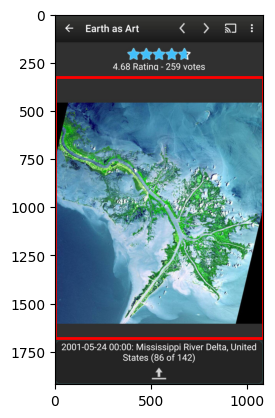

In [ ]:
# Define the bounding box coordinates (from comments in previous cell)
bbox = [0.0, 0.1697479, 1.0, 0.876037]

example_rico_id = uicrit_df['rico_id'][index]  # Get the RICO ID for the example screen

# Load the image and display it with the bounding box
img = cv2.imread(cleaned_dataset_dir + f'/used_dataset_screens/{example_rico_id}.jpg')  # replace with rico_id.jpg
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Calculate the bounding box coordinates based on the image size
h, w, _ = img.shape
x1, y1, x2, y2 = [int(b * s) for b, s in zip(bbox, [w, h, w, h])]

fig, ax = plt.subplots()
ax.imshow(img)
rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.show()


# Statistics

In [ ]:
uicrit_df = pd.read_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet')

print("Data size:", uicrit_df.shape)
uicrit_df.describe()

Data size: (2957, 10)


,rico_id,aesthetics_rating,learnability,efficency,usability_rating,design_quality_rating
count,2957.000000,2957.000000,2957.000000,2957.000000,2957.000000,2957.000000
mean,35932.715252,5.746365,3.007440,3.017247,5.815015,5.815015
std,20926.052798,1.087164,0.611083,0.651874,1.065166,1.020065
min,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,17259.000000,5.000000,3.000000,3.000000,5.000000,5.000000
50%,36234.000000,6.000000,3.000000,3.000000,6.000000,6.000000
75%,53478.000000,6.000000,3.000000,3.000000,6.000000,6.000000
max,72194.000000,10.000000,5.000000,5.000000,10.000000,9.000000


Checking whether the same screen with multiple tasks has the same or different ratings

In [ ]:
# what screens are repeaated in the dataset?
# Count the number of occurrences of each screen (rico_id)
screen_counts = uicrit_df['rico_id'].value_counts()
# Filter screens that appear more than once
repeated_screens = screen_counts[screen_counts > 1]
max_repeated_screens = repeated_screens.max()
print(f"Number of repeated screens: {len(repeated_screens)}")
print(f"Maximum number of times a screen is repeated: {max_repeated_screens}")

Number of repeated screens: 998
Maximum number of times a screen is repeated: 4


In [92]:
ratings = ['aesthetics_rating', 'learnability', 'efficency', 'usability_rating', 'design_quality_rating']

# Count how many repeated screens have different individual ratings
diff_count = 0
for screen_id in repeated_screens.index:
    screen_data = uicrit_df[uicrit_df['rico_id'] == screen_id]
    for evaluate in ratings:
        if screen_data[evaluate].nunique() > 1:
            diff_count += 1
            # print(f"Screen {screen_id} has different values for '{rating}' across entries.")
            break
print(f"Number of repeated screens with different individual ratings: {diff_count}")

Number of repeated screens with different individual ratings: 955


Investigating usability_rating

In [ ]:
# Add a computed column for sum
uicrit_df = pl.from_pandas(uicrit_df)
uicrit_df = uicrit_df.with_columns([
    (pl.col("learnability") + pl.col("efficiency")).alias("sum_learn_eff")
])

# Compare sum with usability_rating
match_df = uicrit_df.with_columns([
    (pl.col("usability_rating") == pl.col("sum_learn_eff")).alias("matches_sum")
])

# Count how many match vs total
matches = match_df.filter(pl.col("matches_sum")).height
total = match_df.height
percent_match = matches / total * 100

print(f"Out of {total} expert ratings, {matches} ({percent_match:.2f}%) have usability_rating equal to learnability + efficiency; indicating possible additive scoring by experts.")

In [ ]:
# count how many times usability_rating column equals the sum of efficiency and learnability
usability_rating_count = uicrit_df[uicrit_df['usability_rating'] == (uicrit_df['efficiency'] + uicrit_df['learnability'])].shape[0]
print(f"Number of rows where usability_rating equals the sum of efficiency and learnability: {usability_rating_count}")
# percent
usability_rating_percent = (usability_rating_count / uicrit_df.shape[0]) * 100
print(f"Percentage: {usability_rating_percent:.2f}%")

Number of rows where usability_rating equals the sum of efficiency and learnability: 894
Percentage: 89.40%


## Rename rico_id into screen_id

In [ ]:
## Rename rico_id into screen_id
uicrit_df = pd.read_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet')
uicrit_df.rename(columns={'rico_id': 'screen_id'}, inplace=True)
# Save the updated DataFrame with renamed column
uicrit_df.to_parquet(cleaned_dataset_dir + '/uicrit_notna_deduped.parquet', index=False)

uicrit_humanfeedback_df = pd.read_parquet(cleaned_dataset_dir + '/uicrit_human-only_feedback.parquet')
uicrit_humanfeedback_df.rename(columns={'rico_id': 'screen_id'}, inplace=True)
# Save the updated DataFrame with renamed column
uicrit_humanfeedback_df.to_parquet(cleaned_dataset_dir + '/uicrit_human-only_feedback.parquet', index=False)